In [29]:
import shap
import joblib
import pandas as pd

Load the Trained Model

In [30]:
rf=joblib.load('customer_churn_model.pkl')

Load the Dataset

In [36]:
df = pd.read_csv("processed_telco_churn.csv")
from sklearn.model_selection import train_test_split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Create SHAP Explainer

In [ ]:
explainer=shap.TreeExplainer(rf)

Calculate SHAP Values

In [ ]:
shap_values = explainer.shap_values(X_test)

Summary Plot

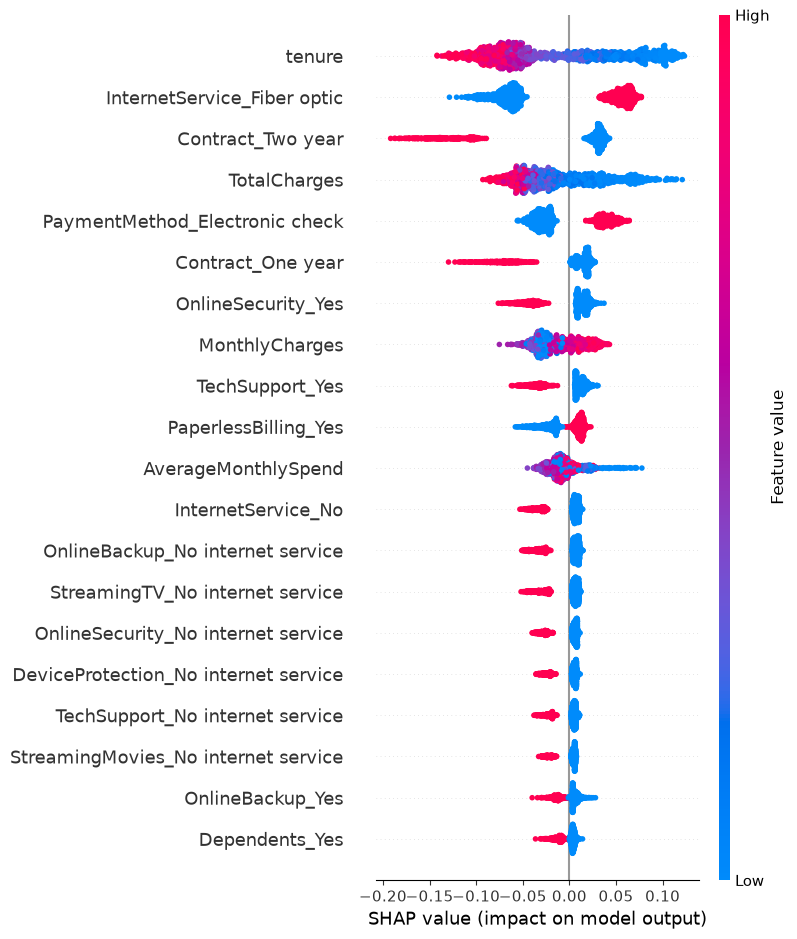

In [ ]:

shap.summary_plot(
    shap_values [:,:,1],X_test
)    

Explain One Customer

In [54]:
shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_values[:,:,1][1],
    X_test.iloc[1]
)

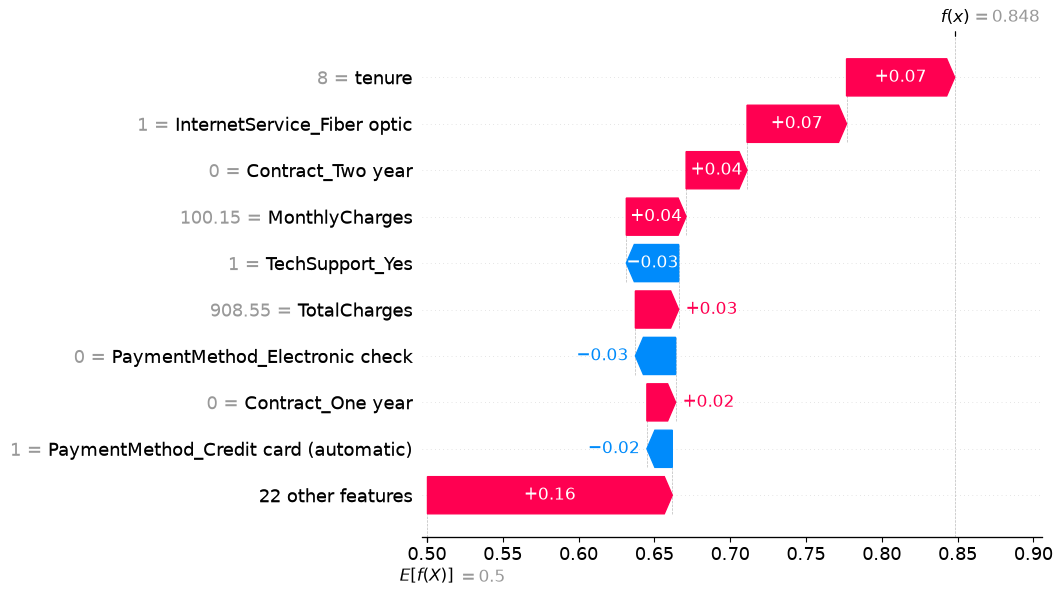

In [56]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[:,:,1][1],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[1],
        feature_names=X_test.columns
    )
)